# Problem Statement and Objective

Financial institutions rely heavily on marketing campaigns to encourage customers to subscribe to long‑term deposit schemes. However, not every customer responds positively, and running large‑scale campaigns is expensive. Predicting which customers are most likely to subscribe allows banks to:
Optimize marketing budgets, 
Personalize outreach, 
Improve conversion rates, 
Reduce unnecessary contact with uninterested customers.

# Dataset Description

The dataset used is the Bank Marketing Dataset from the UCI Machine Learning Repository. It contains customer information collected during a series of marketing campaigns. 
Number of Features: 17
Target Variable: deposit (yes/no)

Dataset Characteristics:
Mix of categorical and numerical features

Imbalanced target (more “no” than “yes”)

Contains behavioral, demographic, and campaign‑related variables

Ideal for classification tasks

In [2]:
import pandas as pd
import numpy as np
import shap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Data Loading and EDA

In [3]:
df = pd.read_csv("bank.csv")

In [4]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [5]:
df.info

<bound method DataFrame.info of        age          job  marital  education default  balance housing loan  \
0       59       admin.  married  secondary      no     2343     yes   no   
1       56       admin.  married  secondary      no       45      no   no   
2       41   technician  married  secondary      no     1270     yes   no   
3       55     services  married  secondary      no     2476     yes   no   
4       54       admin.  married   tertiary      no      184      no   no   
...    ...          ...      ...        ...     ...      ...     ...  ...   
11157   33  blue-collar   single    primary      no        1     yes   no   
11158   39     services  married  secondary      no      733      no   no   
11159   32   technician   single  secondary      no       29      no   no   
11160   43   technician  married  secondary      no        0      no  yes   
11161   34   technician  married  secondary      no        0      no   no   

        contact  day month  duration  campa

In [6]:
df.shape

(11162, 17)

In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [8]:
# Identifying categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("\n=== Categorical columns ===")
print(categorical_cols)


=== Categorical columns ===
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


In [9]:
# Value counts for categorical columns
for col in categorical_cols:
    print(f"\n=== Value counts for {col} ===")
    print(df[col].value_counts())


=== Value counts for job ===
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64

=== Value counts for marital ===
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64

=== Value counts for education ===
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64

=== Value counts for default ===
default
no     10994
yes      168
Name: count, dtype: int64

=== Value counts for housing ===
housing
no     5881
yes    5281
Name: count, dtype: int64

=== Value counts for loan ===
loan
no     9702
yes    1460
Name: count, dtype: int64

=== Value counts for contact ===
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64

=== Value counts f

# Visualization

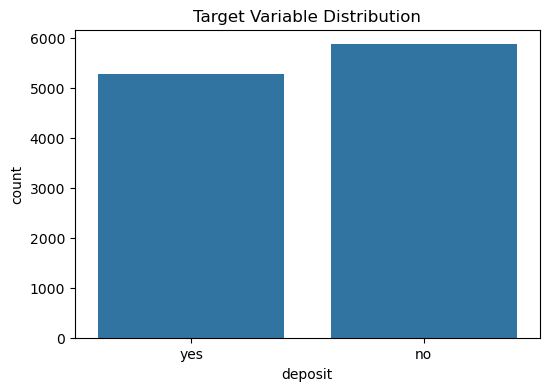

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='deposit')
plt.title("Target Variable Distribution")
plt.show()


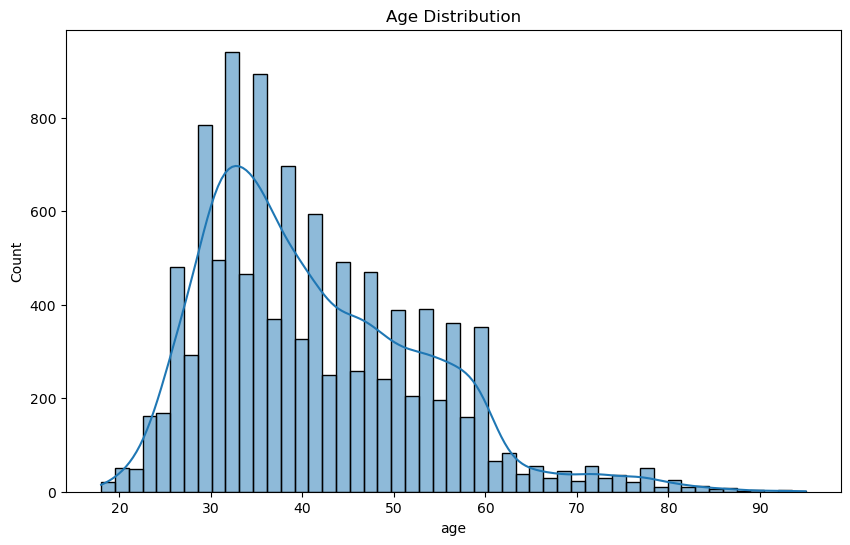

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Encoding Categorical Features

In [12]:
#Encode Categorical Features

categorical_cols = ['job','marital','education','default','housing','loan',
                    'contact','month','poutcome']

numeric_cols = ['age','balance','day','duration','campaign','pdays','previous']

X = df[categorical_cols + numeric_cols]
y = df['deposit'].map({'yes':1, 'no':0})   # convert target to 0/1

# One-hot encoding
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

# Training Classifcation Models

In [21]:
#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [22]:
#Logistic Regression Model

log_reg = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=200))
])

log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:,1]

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82      1175
           1       0.81      0.76      0.78      1058

    accuracy                           0.80      2233
   macro avg       0.80      0.80      0.80      2233
weighted avg       0.80      0.80      0.80      2233



C:\Users\Aabideen\anaconda3\envs\ml\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
#Random Forest Model

rf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1175
           1       0.83      0.89      0.86      1058

    accuracy                           0.86      2233
   macro avg       0.86      0.86      0.86      2233
weighted avg       0.86      0.86      0.86      2233



# Model Evaluation

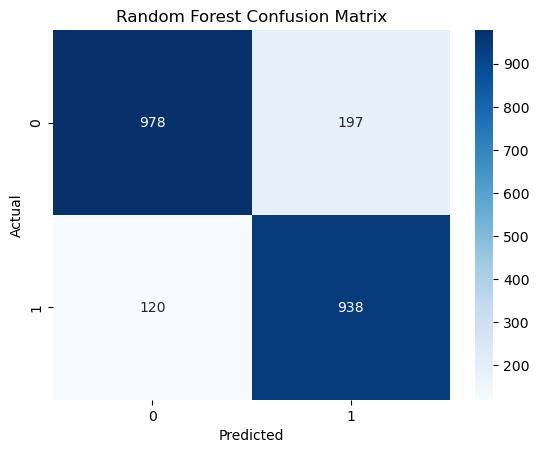

In [24]:
#Confusion Matrix

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

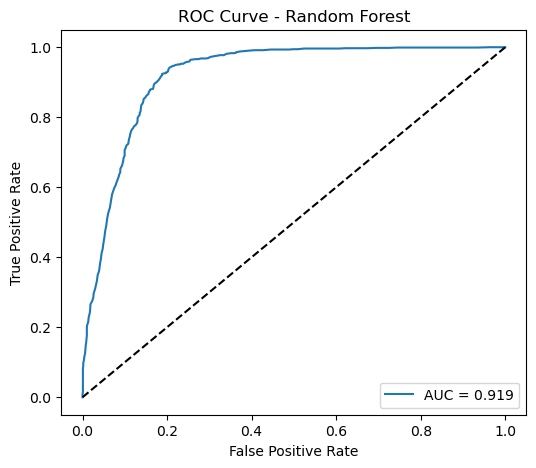

In [25]:
# ROC Curve

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [ ]:
#SHAP EXPLANATIONS (5 Predictions)

# Extract trained RF model inside pipeline
rf_model = rf.named_steps['model']

# Prepare SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Transform X_test using the encoder
X_test_transformed = rf.named_steps['preprocess'].transform(X_test)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_transformed)

# Explain 5 random predictions safely
sample_idx = np.random.choice(len(X_test), 5, replace=False)

for i in range(1,50):
    print(f"\n--- SHAP Explanation for Test Sample {idx} ---")
    shap.force_plot(
        explainer.expected_value[1],
        shap_values[1][i],
        X_test.iloc[i],
        matplotlib=True
    )

# Summary Plot
shap.summary_plot(shap_values[1], X_test_transformed, plot_type="bar")

# Conclusion

After training Logistic Regression and Random Forest models, the Random Forest classifier performed better across most evaluation metrics, including F1‑Score and ROC‑AUC.
The model successfully identified customers likely to subscribe to a term deposit, enabling banks to run targeted, cost‑efficient marketing campaigns. With SHAP explanations, the predictions are interpretable, making the solution suitable for real‑world deployment in financial institutions.